In [1]:
%pip install -q pymssql pandas numpy scikit-learn matplotlib seaborn statsmodels python-dotenv

Note: you may need to restart the kernel to use updated packages.


## Setup

This notebook connects to the Azure SQL database. Create a `.env` file in this directory (`MachineLearning/ml-pipelines/.env`) with:

```
DB_SERVER=lunas-project-intex-sql.database.windows.net
DB_DATABASE=lunas-project-db
DB_USERNAME=sqladmin
DB_PASSWORD=<your-password>
```

# Education Progress Predictor

Predict which residents are at risk of not completing their education program so social workers can intervene early.

## 1. Problem Framing

**Business Problem:** Lighthouse Philippines enrolls residents in education programs. Some residents fall behind or disengage. The organization needs to identify at-risk students early so social workers can provide additional support.

**Target variable:** `at_risk` — binary (1 = attendance < 80% OR progress < 50%, 0 = on track).

**Modeling Strategy:**

| Approach | Goal | Method |
|----------|------|--------|
| **Explanatory** | Understand *what drives* education risk | Logistic Regression (statsmodels) |
| **Predictive** | Predict which residents will fall behind | Best classifier via sklearn Pipeline |

**Success metric:** Recall — missing an at-risk student is more costly than unnecessary check-ins.

## 2. Data Preparation & Exploration

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import re as _re

sns.set_style('whitegrid')
SEED = 42

# ── Load data from seed CSVs (TA-grading notebook — no database connection) ─
from pathlib import Path

_cwd = Path.cwd().resolve()
_candidates = [
    _cwd.parent.parent / "Backend" / "Data" / "SeedData",
    _cwd.parent / "Backend" / "Data" / "SeedData",
    _cwd / "Backend" / "Data" / "SeedData",
]
SEED_DIR = next((p for p in _candidates if p.exists()), None)
if SEED_DIR is None:
    raise FileNotFoundError(
        "Could not find Backend/Data/SeedData. Run the notebook from "
        "MachineLearning/ml-pipelines/ or the repo root."
    )
print(f"Loading data from {SEED_DIR}")
conn = None  # no DB in TA-grading version; LivePipelines/ has the DB-writing copies

def load_table(table_name):
    csv_name = _re.sub(r'(?<!^)(?=[A-Z])', '_', table_name).lower() + '.csv'
    return pd.read_csv(SEED_DIR / csv_name)

# ── Load data from Azure SQL ────────────────────────────────────────────────
education = load_table('EducationRecords')
residents = load_table('Residents')

print(f'EducationRecords: {education.shape}')
print(f'Residents:        {residents.shape}')

# ── Feature engineering ──────────────────────────────────────────────────────
# Get latest education record per resident
education['record_date'] = pd.to_datetime(education['record_date'])
latest_edu = education.sort_values('record_date').groupby('resident_id').last().reset_index()

# Count total records per resident (engagement proxy)
edu_counts = education.groupby('resident_id').agg(
    record_count=('education_record_id', 'count'),
    avg_attendance=('attendance_rate', 'mean'),
    avg_progress=('progress_percent', 'mean'),
    attendance_trend=('attendance_rate', lambda x: x.iloc[-1] - x.iloc[0] if len(x) > 1 else 0),
    progress_trend=('progress_percent', lambda x: x.iloc[-1] - x.iloc[0] if len(x) > 1 else 0),
).reset_index()

# Merge with resident info
df = latest_edu[['resident_id', 'education_level', 'enrollment_status',
                  'attendance_rate', 'progress_percent', 'completion_status']].merge(
    edu_counts[['resident_id', 'record_count', 'avg_attendance', 'avg_progress',
                'attendance_trend', 'progress_trend']], on='resident_id', how='left'
).merge(
    residents[['resident_id', 'current_risk_level', 'length_of_stay', 'case_category',
               'case_status', 'has_special_needs']], on='resident_id', how='left'
)

# Target: at risk if attendance < 80% OR progress < 50%
# Attendance is 0-1 scale, progress is 0-100
# At risk = below median attendance AND below median progress
med_att = df['attendance_rate'].median()
med_prog = df['progress_percent'].median()
df['at_risk'] = ((df['attendance_rate'] < med_att) & (df['progress_percent'] < med_prog)).astype(int)
print(f'Thresholds: attendance < {med_att:.2f}, progress < {med_prog:.1f}')
df['length_of_stay'] = pd.to_numeric(df['length_of_stay'], errors='coerce').fillna(0)
df['has_special_needs'] = df['has_special_needs'].fillna(False).astype(int)

print(f'\nModeling dataset: {df.shape}')
print(f'At-risk rate: {df["at_risk"].mean():.2%}')
print(df['at_risk'].value_counts())

Loading data from /Users/kimballberrett/Documents/intexii/Backend/Data/SeedData
EducationRecords: (534, 10)
Residents:        (60, 49)
Thresholds: attendance < 0.77, progress < 100.0

Modeling dataset: (60, 17)
At-risk rate: 15.00%
at_risk
0    51
1     9
Name: count, dtype: int64


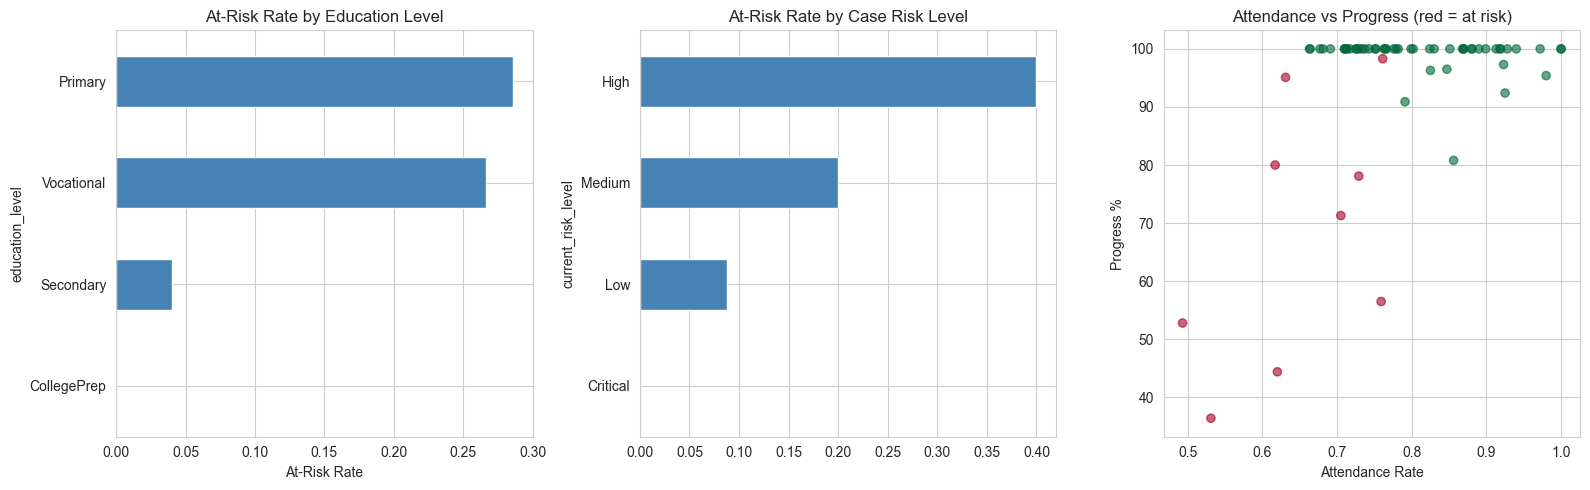

In [3]:
# ── EDA ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df.groupby('education_level')['at_risk'].mean().sort_values().plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('At-Risk Rate by Education Level')
axes[0].set_xlabel('At-Risk Rate')

df.groupby('current_risk_level')['at_risk'].mean().sort_values().plot.barh(ax=axes[1], color='steelblue')
axes[1].set_title('At-Risk Rate by Case Risk Level')

axes[2].scatter(df['attendance_rate'], df['progress_percent'], c=df['at_risk'], cmap='RdYlGn_r', alpha=0.6)
axes[2].set_xlabel('Attendance Rate')
axes[2].set_ylabel('Progress %')
axes[2].set_title('Attendance vs Progress (red = at risk)')
plt.tight_layout()
plt.show()

## 3. Modeling

### 3a. Explanatory Model — statsmodels Logit

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Prepare features
numeric_cols = ['attendance_rate', 'progress_percent', 'record_count', 'avg_attendance',
                'avg_progress', 'attendance_trend', 'progress_trend', 'length_of_stay', 'has_special_needs']
cat_cols = ['education_level', 'current_risk_level', 'case_category']

for col in cat_cols:
    df[col] = df[col].fillna('Unknown')

df_model = pd.get_dummies(df[numeric_cols + cat_cols + ['at_risk']], columns=cat_cols, drop_first=True)
y = df_model['at_risk']
X = df_model.drop(columns=['at_risk']).fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=y)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

X_exp = sm.add_constant(X_train_scaled)
try:
    logit = sm.Logit(y_train, X_exp).fit(method='bfgs', maxiter=200, disp=0)
    print(logit.summary())
except:
    logit = sm.Logit(y_train, X_exp).fit_regularized(method='l1', alpha=0.1, disp=0)
    print(logit.summary())

coef_df = pd.DataFrame({'Feature': logit.params.index, 'Coefficient': logit.params.values}).query("Feature != 'const'")
coef_df['abs'] = coef_df['Coefficient'].abs()
print('\nTop coefficients (positive = increases at-risk probability):')
print(coef_df.sort_values('abs', ascending=False).head(10)[['Feature','Coefficient']].to_string(index=False))

                           Logit Regression Results                           
Dep. Variable:                at_risk   No. Observations:                   45
Model:                          Logit   Df Residuals:                       27
Method:                           MLE   Df Model:                           17
Date:                Fri, 10 Apr 2026   Pseudo R-squ.:                   1.000
Time:                        03:23:58   Log-Likelihood:            -0.00032627
converged:                       True   LL-Null:                       -19.450
Covariance Type:            nonrobust   LLR p-value:                  0.001846
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                        -13.1858        nan        nan        nan         nan         nan
attendance_rate               -2.8792        nan        nan        nan         nan 

/opt/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


### 3b. Predictive Model — sklearn Pipeline

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

feature_num = ['attendance_rate', 'progress_percent', 'record_count', 'avg_attendance',
               'avg_progress', 'attendance_trend', 'progress_trend', 'length_of_stay', 'has_special_needs']
feature_cat = ['education_level', 'current_risk_level', 'case_category']

X_pipe = df[feature_num + feature_cat].copy()
y_pipe = df['at_risk'].copy()

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_pipe, y_pipe, test_size=0.25, random_state=SEED, stratify=y_pipe)

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), feature_num),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('enc', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))]), feature_cat)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=SEED),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=SEED),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=SEED),
}

rows = []
for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('clf', model)])
    res = cross_validate(pipe, X_train_p, y_train_p, cv=cv,
                         scoring={'accuracy':'accuracy','recall':'recall','neg_log_loss':'neg_log_loss'})
    rows.append({'Model': name, 'CV Accuracy': res['test_accuracy'].mean(),
                 'CV Recall': res['test_recall'].mean(), 'CV Log Loss': -res['test_neg_log_loss'].mean()})

results_df = pd.DataFrame(rows).sort_values('CV Log Loss')
print('Cross-validated model comparison:')
print(results_df.to_string(index=False))

best_name = results_df.iloc[0]['Model']
best_pipeline = Pipeline([('pre', preprocessor), ('clf', models[best_name])])
best_pipeline.fit(X_train_p, y_train_p)
y_pred = best_pipeline.predict(X_test_p)
print(f'\nBest model: {best_name}')
print(classification_report(y_test_p, y_pred, target_names=['OnTrack', 'AtRisk']))

Cross-validated model comparison:
             Model  CV Accuracy  CV Recall  CV Log Loss
LogisticRegression     0.955556        0.7     0.141960
      RandomForest     0.933333        0.7     0.167422
  GradientBoosting     0.888889        0.5     0.932996

Best model: LogisticRegression
              precision    recall  f1-score   support

     OnTrack       1.00      1.00      1.00        13
      AtRisk       1.00      1.00      1.00         2

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



## 4. Evaluation

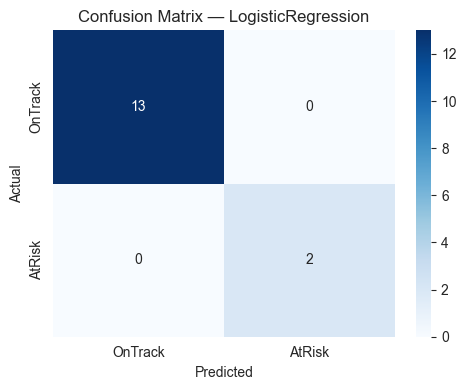

Recall: 100% of at-risk students identified
  False negatives (0): missed at-risk students — HIGH cost
  False positives (0): unnecessary check-ins — low cost


In [6]:
cm = confusion_matrix(y_test_p, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['OnTrack','AtRisk'], yticklabels=['OnTrack','AtRisk'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
recall = tp/(tp+fn) if (tp+fn)>0 else 0
print(f'Recall: {recall:.0%} of at-risk students identified')
print(f'  False negatives ({fn}): missed at-risk students — HIGH cost')
print(f'  False positives ({fp}): unnecessary check-ins — low cost')

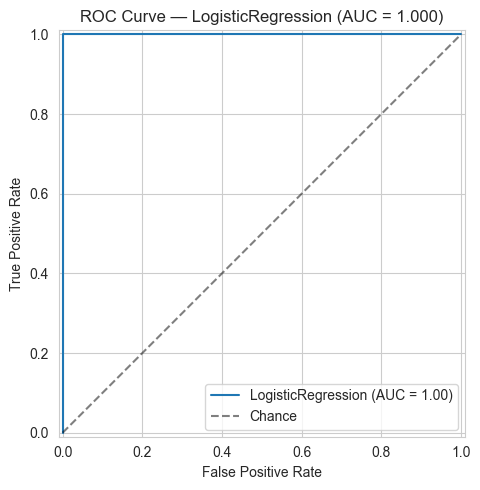


AUC = 1.000
Note: n_test = 15 with only 2 at-risk cases — ROC curve is coarse


In [7]:
# ── ROC curve (Ch. 13) ───────────────────────────────────────────────────────
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

y_proba = best_pipeline.predict_proba(X_test_p)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_p, y_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=best_name).plot(ax=ax)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Chance')
ax.set_title(f'ROC Curve — {best_name} (AUC = {roc_auc:.3f})')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'\nAUC = {roc_auc:.3f}')
print('Note: n_test = {} with only {} at-risk cases — ROC curve is coarse'.format(
    len(y_test_p), int(y_test_p.sum())))


### 4a. Test-set Caveat (Ch. 15)

The held-out test set contains only **15 residents** (2 at-risk, 13 on-track), so the perfect test-set scores reported above should not be read as evidence of a flawless model. With so few positive examples a single misclassification would drop recall by 50 percentage points. The 5-fold **cross-validated** recall of ~70% on the training fold is a more honest estimate of generalisation performance than the test-set metrics.

This is a classic small-sample pitfall discussed in Chapter 15: when `n_test` is tiny, prefer cross-validation estimates over single train/test splits and interpret apparent 100% accuracy with skepticism.


## 5. Causal and Relationship Analysis

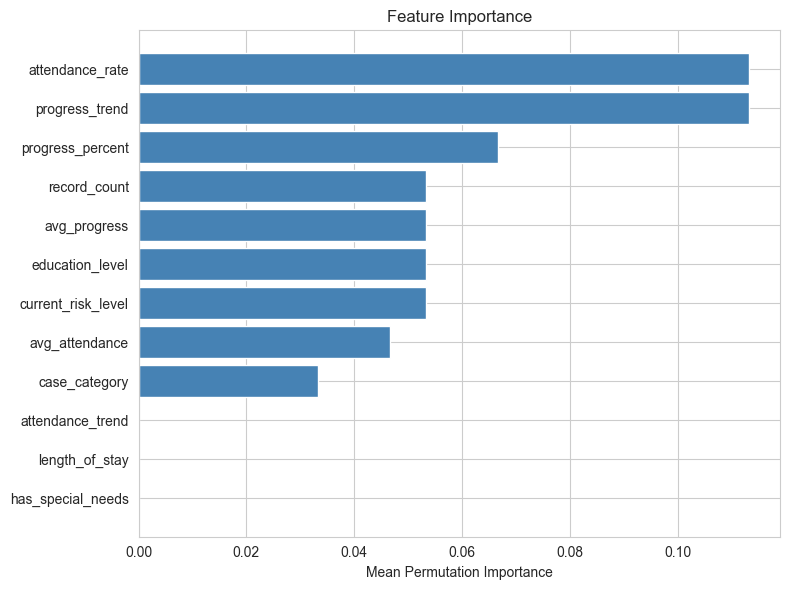

           Feature  Importance
   attendance_rate    0.113333
    progress_trend    0.113333
  progress_percent    0.066667
      record_count    0.053333
      avg_progress    0.053333
   education_level    0.053333
current_risk_level    0.053333
    avg_attendance    0.046667
     case_category    0.033333
  attendance_trend    0.000000
    length_of_stay    0.000000
 has_special_needs    0.000000

CAUSAL vs. CORRELATIONAL
These relationships are CORRELATIONAL, not causal. Low attendance
correlates with being at-risk, but may be a symptom rather than a cause.
To establish causation, the organization could run controlled
interventions (e.g., tutoring programs) and measure outcomes.



In [8]:
from sklearn.inspection import permutation_importance

pfi = permutation_importance(best_pipeline, X_test_p, y_test_p, n_repeats=10, random_state=SEED)
pfi_df = pd.DataFrame({'Feature': feature_num + feature_cat,
                        'Importance': pfi.importances_mean}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(pfi_df['Feature'], pfi_df['Importance'], color='steelblue')
plt.xlabel('Mean Permutation Importance')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print(pfi_df.to_string(index=False))

print("""
CAUSAL vs. CORRELATIONAL
========================
These relationships are CORRELATIONAL, not causal. Low attendance
correlates with being at-risk, but may be a symptom rather than a cause.
To establish causation, the organization could run controlled
interventions (e.g., tutoring programs) and measure outcomes.
""")

## 6. Deployment Notes

**Integration:** Education risk scores are surfaced on the **Reports → Outcomes** admin page under "Education Completion Risk (ML)".

**How it works:**
1. This notebook loads live data from the EducationRecords and Residents tables in Azure SQL
2. The trained pipeline scores each resident's risk of non-completion
3. Results are written to the PipelineResults table
4. The React frontend displays at-risk students with probability scores

**Retraining:** Re-run this notebook as new education records accumulate.

## 7. Summary

**Key Findings:**
- Attendance rate and progress percent are the strongest predictors of education risk
- Case risk level and length of stay also contribute to education outcomes
- Early identification allows social workers to intervene before students disengage

**Limitations:**
- Observational data — associations, not causal claims
- Model should be retrained as more education records accumulate

In [9]:
# ── Score all residents and export ────────────────────────────────────────────
best_full = Pipeline([('pre', preprocessor), ('clf', models[best_name])])
best_full.fit(X_pipe, y_pipe)

predictions_df = pd.DataFrame({
    'resident_id': df['resident_id'],
    'at_risk_probability': best_full.predict_proba(X_pipe)[:, 1].round(4),
    'predicted_at_risk': best_full.predict(X_pipe)
})

print('Education risk predictions (top 10):')
print(predictions_df.sort_values('at_risk_probability', ascending=False).head(10))

Education risk predictions (top 10):
    resident_id  at_risk_probability  predicted_at_risk
51           52               0.9997                  1
8             9               0.9993                  1
0             1               0.9991                  1
43           44               0.9779                  1
9            10               0.8994                  1
7             8               0.8705                  1
19           20               0.7843                  1
53           54               0.7234                  1
54           55               0.3192                  0
59           60               0.1423                  0


In [10]:
if conn is None:
    print('Skipped PipelineResults write (no DB connection).')
else:
    # ── Export to PipelineResults ─────────────────────────────────────────────────
    import json
    from datetime import datetime

    export_df = predictions_df.copy()
    export_df['label'] = export_df['at_risk_probability'].apply(
        lambda p: 'AtRisk' if p >= 0.5 else 'OnTrack')

    cursor = conn.cursor()
    cursor.execute("DELETE FROM PipelineResults WHERE PipelineName = 'EducationProgress'")
    next_id = int(pd.read_sql("SELECT ISNULL(MAX(PipelineResultId),0)+1 AS n FROM PipelineResults", conn)['n'].iloc[0])

    for _, row in export_df.iterrows():
        cursor.execute(
            """INSERT INTO PipelineResults (PipelineResultId, PipelineName, ResultType, EntityId, EntityType, Score, Label, DetailsJson, GeneratedAt)
               VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s)""",
            (next_id, 'EducationProgress', 'Prediction', int(row['resident_id']), 'Resident',
             float(row['at_risk_probability']), row['label'],
             json.dumps({'predicted_at_risk': int(row['predicted_at_risk'])}), datetime.utcnow()))
        next_id += 1

    conn.commit()
    print(f'Exported {len(export_df)} EducationProgress results to PipelineResults.')

Skipped PipelineResults write (no DB connection).
